In [ ]:
import os, sys, torch, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# -------------------- 路径 & 导入 --------------------
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)

import models as models
import train_helper as train_helper
import data_helper as data_helper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print(f"[INFO] device = {device}")

# -------------------- 加载你指定的生成器 --------------------
GEN_CKPT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae/model_saved_more/cvae_conv_real_500.pth"
assert os.path.exists(GEN_CKPT), f"Missing generator checkpoint: {GEN_CKPT}"

gen_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv").to(device)
gen_model.load_state_dict(torch.load(GEN_CKPT, map_location=device))
gen_model.eval()
print(f"[LOAD] generator <- {GEN_CKPT}")

# -------------------- 准备真实数据 --------------------
transform = transforms.ToTensor()
train_real = datasets.MNIST(root=os.path.join(VAE_ROOT, "data"), train=True, download=True, transform=transform)

# -------------------- 用该生成器构造判别器训练数据并训练判别器 --------------------
print("[BUILD] preparing discriminator dataset (real vs generated-by-cvae500)...")
disc_dataset = data_helper.prepare_discriminator_dataset(train_real, gen_model, device)
disc_loader  = DataLoader(disc_dataset, batch_size=128, shuffle=True)

disc_model = models.SyntheticDiscriminator(input_dim=784).to(device)
print("[TRAIN] training discriminator...")
train_helper.train_model(
    model=disc_model,
    train_loader=disc_loader,
    device=device,
    epochs=80,
    lr=1e-3,
    patience=5,
    verbose=False
)
disc_model.eval()
print("[DONE] discriminator trained.")

# (可选) 保存判别器
SAVE_DIR = os.path.join(VAE_ROOT, "results_saved_more")
os.makedirs(SAVE_DIR, exist_ok=True)
DISC_CKPT = os.path.join(SAVE_DIR, "disc_on_cvae500.pth")
torch.save(disc_model.state_dict(), DISC_CKPT)
print(f"[SAVE] discriminator -> {DISC_CKPT}")

# -------------------- 生成独立评估集（来自同一生成器） --------------------
@torch.no_grad()
def gen_samples(generator, total=6000, latent_dim=20, num_classes=10, batch=3000, device=device):
    outs = []
    for start in range(0, total, batch):
        n = min(batch, total - start)
        z = torch.randn(n, latent_dim, device=device)
        y = (torch.arange(n, device=device) + start) % num_classes
        y1h = F.one_hot(y, num_classes=num_classes).float()
        logits = generator.decoder.decode(z, y1h)
        imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)
        outs.append(imgs.cpu())
    return torch.cat(outs, dim=0)


[INFO] device = cuda
[LOAD] generator <- /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae/model_saved_more/cvae_conv_real_500.pth


/tmp/ipykernel_830935/2991287330.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_model.load_state_dict(torch.load(GEN_CKPT, map_location=device))


[BUILD] preparing discriminator dataset (real vs generated-by-cvae500)...
[TRAIN] training discriminator...
[DONE] discriminator trained.
[SAVE] discriminator -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_more/disc_on_cvae500.pth
[GEN] sampling evaluation set from generator...
[EVAL] discriminator on generated samples...
[EVAL] discriminator on real samples (for comparison/AUC)...


In [ ]:

print("[GEN] sampling evaluation set from generator...")
gen_eval = gen_samples(gen_model, total=60000)

# -------------------- 判别器在生成样本上的输出分布 --------------------
@torch.no_grad()
def disc_probs(disc, images, batch=1024, device=device):
    probs = []
    for i in range(0, images.size(0), batch):
        x = images[i:i+batch].to(device).view(-1, 784)
        p = torch.sigmoid(disc(x)).squeeze()
        probs.append(p.detach().cpu())
    return torch.cat(probs).numpy()

print("[EVAL] discriminator on generated samples...")
pvals_gen = disc_probs(disc_model, gen_eval)

import torch
import matplotlib.pyplot as plt

# 确保 gen_eval 和 pvals_gen 已经在内存中
assert 'gen_eval' in locals() and 'pvals_gen' in locals(), "请先运行生成与判别步骤"

[INFO] 10th percentile threshold = 0.0000


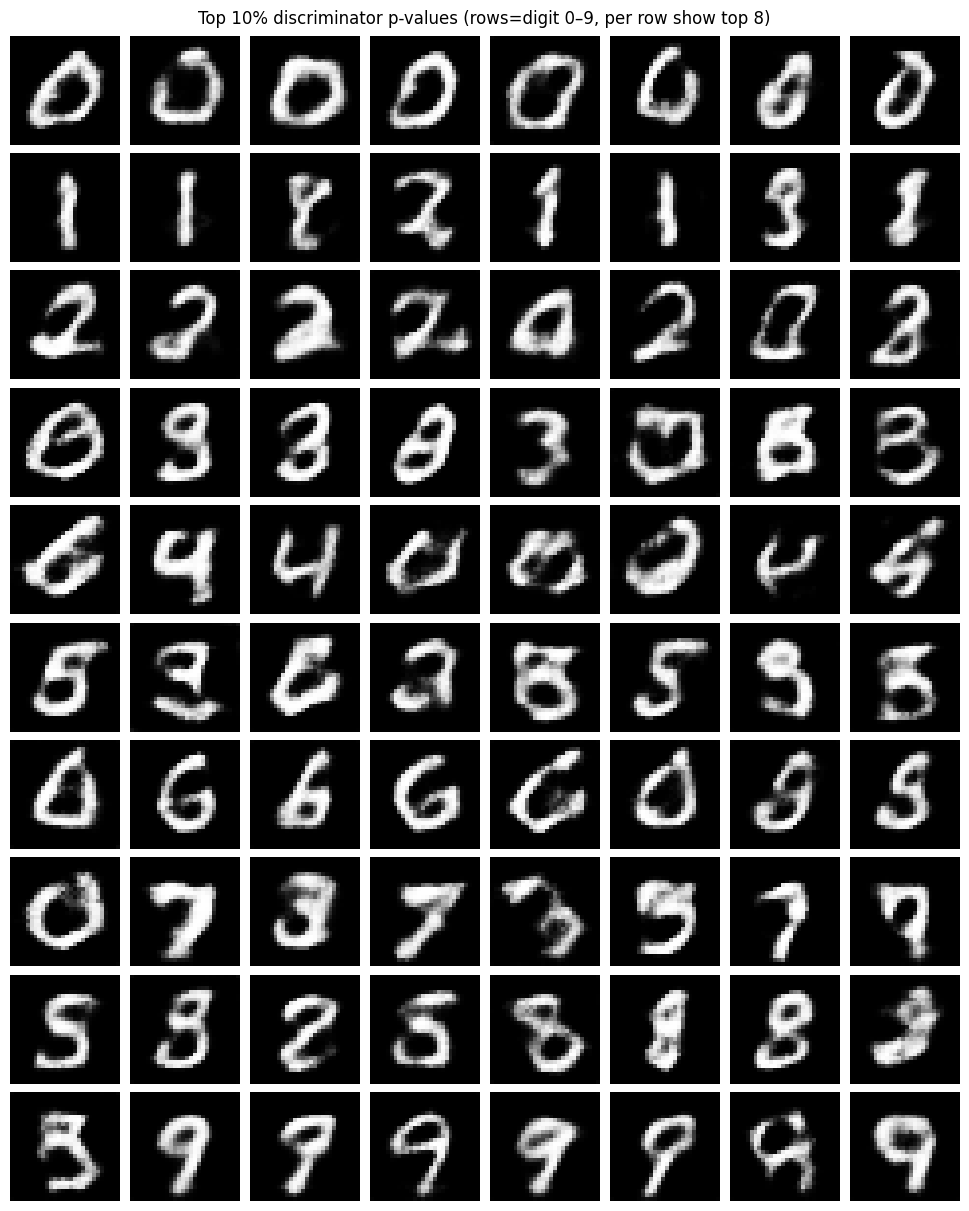

In [8]:
# ==================== 每一行一个 digit，且每类只取 Top-K（更快） ====================
import numpy as np
import matplotlib.pyplot as plt

num_classes = 10
total = gen_eval.shape[0]
labels = np.arange(total) % num_classes

# 仍然用 top-10% 做筛选，但只展示每类前 K 张
top_percent = 0.10
K = 8  # 每个 digit 显示的样本数（可调小到 10 进一步加速）

threshold = np.quantile(pvals_gen, 1 - top_percent)
print(f"[INFO] {int(top_percent*100)}th percentile threshold = {threshold:.4f}")
top_mask = pvals_gen >= threshold

# 为每个类别选出 top-K（用 argpartition 比 sort 更快）
top_indices_per_class = []
for c in range(num_classes):
    idx_c = np.where((labels == c) & top_mask)[0]
    if len(idx_c) > K:
        # 取 p 值最大的 K 个索引（先 argpartition 再按分数降序排序这 K 个）
        part = np.argpartition(pvals_gen[idx_c], -K)[-K:]
        best_local = idx_c[part]
        best_local = best_local[np.argsort(pvals_gen[best_local])[::-1]]
        top_indices_per_class.append(best_local)
    else:
        # 不足 K 的就全要，再按分数从大到小排序（视觉更一致）
        best_local = idx_c[np.argsort(pvals_gen[idx_c])[::-1]]
        top_indices_per_class.append(best_local)

# 画固定 10 x K 网格（空位留白）
rows, cols = num_classes, K
fig, axes = plt.subplots(rows, cols, figsize=(1.2*cols, 1.2*rows))
if rows == 1:  # 兼容 K 很小的极端情况
    axes = np.expand_dims(axes, 0)

for r in range(rows):
    inds = top_indices_per_class[r]
    for c in range(cols):
        ax = axes[r, c]
        ax.axis("off")
        if c < len(inds):
            img = gen_eval[inds[c], 0].numpy()
            ax.imshow(img, cmap="gray", interpolation="nearest")

# 左侧加行标签（数字类别）
for r in range(rows):
    axes[r, 0].set_ylabel(str(r), rotation=0, labelpad=10, va="center", fontsize=10)

fig.suptitle(f"Top {int(top_percent*100)}% discriminator p-values (rows=digit 0–9, per row show top {K})",
             fontsize=12)
# 避免 tight_layout 的额外计算开销；constrained_layout 更快些
fig.set_constrained_layout(True)

out_path = os.path.join(SAVE_DIR, f"top{int(top_percent*100)}_by_digit_top{K}.png")
#fig.savefig(out_path, dpi=140)
plt.show()


In [9]:
import os, sys, torch, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# -------------------- 路径 & 导入 --------------------
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)

import models as models
import train_helper as train_helper
import data_helper as data_helper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print(f"[INFO] device = {device}")

# -------------------- 加载你指定的生成器 --------------------
GEN_CKPT1 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset/full_dataset_model.pth"
assert os.path.exists(GEN_CKPT1), f"Missing generator checkpoint: {GEN_CKPT}"

gen_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv").to(device)
gen_model.load_state_dict(torch.load(GEN_CKPT1, map_location=device))
gen_model.eval()
print(f"[LOAD] generator <- {GEN_CKPT1}")

# -------------------- 准备真实数据 --------------------
transform = transforms.ToTensor()
train_real = datasets.MNIST(root=os.path.join(VAE_ROOT, "data"), train=True, download=True, transform=transform)

# -------------------- 用该生成器构造判别器训练数据并训练判别器 --------------------
print("[BUILD] preparing discriminator dataset (real vs generated-by-cvae500)...")
disc_dataset = data_helper.prepare_discriminator_dataset(train_real, gen_model, device)
disc_loader  = DataLoader(disc_dataset, batch_size=128, shuffle=True)

disc_model = models.SyntheticDiscriminator(input_dim=784).to(device)
print("[TRAIN] training discriminator...")
train_helper.train_model(
    model=disc_model,
    train_loader=disc_loader,
    device=device,
    epochs=80,
    lr=1e-3,
    patience=5,
    verbose=False
)
disc_model.eval()
print("[DONE] discriminator trained.")

# (可选) 保存判别器
SAVE_DIR = os.path.join(VAE_ROOT, "results_saved_more")
os.makedirs(SAVE_DIR, exist_ok=True)
DISC_CKPT = os.path.join(SAVE_DIR, "disc_on_cvae500.pth")
torch.save(disc_model.state_dict(), DISC_CKPT)
print(f"[SAVE] discriminator -> {DISC_CKPT}")

# -------------------- 生成独立评估集（来自同一生成器） --------------------
@torch.no_grad()
def gen_samples(generator, total=6000, latent_dim=20, num_classes=10, batch=3000, device=device):
    outs = []
    for start in range(0, total, batch):
        n = min(batch, total - start)
        z = torch.randn(n, latent_dim, device=device)
        y = (torch.arange(n, device=device) + start) % num_classes
        y1h = F.one_hot(y, num_classes=num_classes).float()
        logits = generator.decoder.decode(z, y1h)
        imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)
        outs.append(imgs.cpu())
    return torch.cat(outs, dim=0)


[INFO] device = cuda
[LOAD] generator <- /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset/full_dataset_model.pth
[BUILD] preparing discriminator dataset (real vs generated-by-cvae500)...


/tmp/ipykernel_830935/495515714.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_model.load_state_dict(torch.load(GEN_CKPT1, map_location=device))


[TRAIN] training discriminator...
[DONE] discriminator trained.
[SAVE] discriminator -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_more/disc_on_cvae500.pth


/tmp/ipykernel_830935/1080083890.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_model.load_state_dict(torch.load(GEN_CKPT, map_location=device))


[GEN] sampling evaluation set from generator...
[EVAL] discriminator on generated samples...
[INFO] 10th percentile threshold = 0.0499


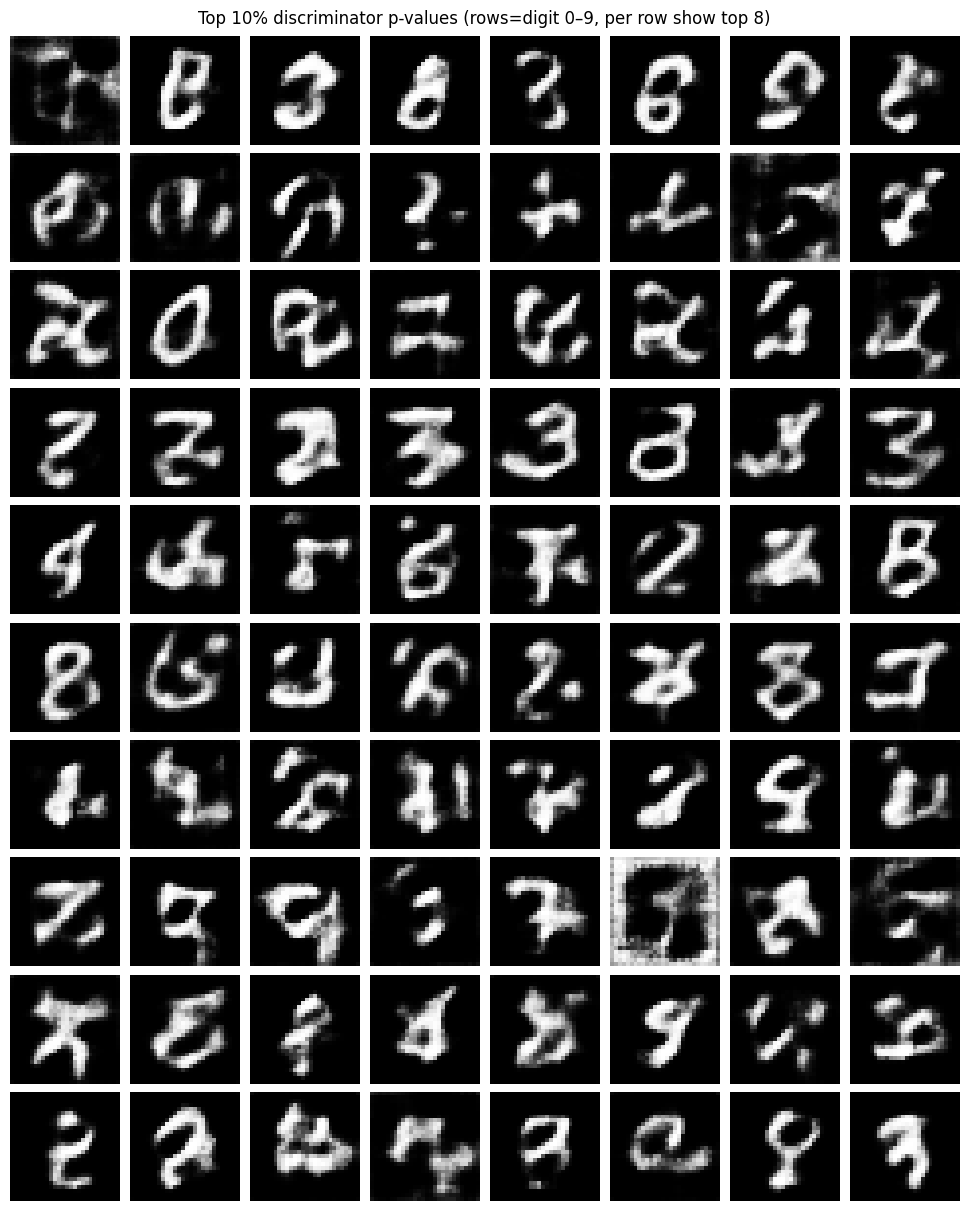

In [10]:
GEN_CKPT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae/model_saved_more/cvae_conv_real_500.pth"
assert os.path.exists(GEN_CKPT), f"Missing generator checkpoint: {GEN_CKPT}"

gen_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv").to(device)
gen_model.load_state_dict(torch.load(GEN_CKPT, map_location=device))
gen_model.eval()

print("[GEN] sampling evaluation set from generator...")
gen_eval = gen_samples(gen_model, total=60000)

# -------------------- 判别器在生成样本上的输出分布 --------------------
@torch.no_grad()
def disc_probs(disc, images, batch=1024, device=device):
    probs = []
    for i in range(0, images.size(0), batch):
        x = images[i:i+batch].to(device).view(-1, 784)
        p = torch.sigmoid(disc(x)).squeeze()
        probs.append(p.detach().cpu())
    return torch.cat(probs).numpy()

print("[EVAL] discriminator on generated samples...")
pvals_gen = disc_probs(disc_model, gen_eval)

import torch
import matplotlib.pyplot as plt

# 确保 gen_eval 和 pvals_gen 已经在内存中
assert 'gen_eval' in locals() and 'pvals_gen' in locals(), "请先运行生成与判别步骤"

# ==================== 每一行一个 digit，且每类只取 Top-K（更快） ====================
import numpy as np
import matplotlib.pyplot as plt

num_classes = 10
total = gen_eval.shape[0]
labels = np.arange(total) % num_classes

# 仍然用 top-10% 做筛选，但只展示每类前 K 张
top_percent = 0.10
K = 8  # 每个 digit 显示的样本数（可调小到 10 进一步加速）

threshold = np.quantile(pvals_gen, 1 - top_percent)
print(f"[INFO] {int(top_percent*100)}th percentile threshold = {threshold:.4f}")
top_mask = pvals_gen >= threshold

# 为每个类别选出 top-K（用 argpartition 比 sort 更快）
top_indices_per_class = []
for c in range(num_classes):
    idx_c = np.where((labels == c) & top_mask)[0]
    if len(idx_c) > K:
        # 取 p 值最大的 K 个索引（先 argpartition 再按分数降序排序这 K 个）
        part = np.argpartition(pvals_gen[idx_c], -K)[-K:]
        best_local = idx_c[part]
        best_local = best_local[np.argsort(pvals_gen[best_local])[::-1]]
        top_indices_per_class.append(best_local)
    else:
        # 不足 K 的就全要，再按分数从大到小排序（视觉更一致）
        best_local = idx_c[np.argsort(pvals_gen[idx_c])[::-1]]
        top_indices_per_class.append(best_local)

# 画固定 10 x K 网格（空位留白）
rows, cols = num_classes, K
fig, axes = plt.subplots(rows, cols, figsize=(1.2*cols, 1.2*rows))
if rows == 1:  # 兼容 K 很小的极端情况
    axes = np.expand_dims(axes, 0)

for r in range(rows):
    inds = top_indices_per_class[r]
    for c in range(cols):
        ax = axes[r, c]
        ax.axis("off")
        if c < len(inds):
            img = gen_eval[inds[c], 0].numpy()
            ax.imshow(img, cmap="gray", interpolation="nearest")

# 左侧加行标签（数字类别）
for r in range(rows):
    axes[r, 0].set_ylabel(str(r), rotation=0, labelpad=10, va="center", fontsize=10)

fig.suptitle(f"Top {int(top_percent*100)}% discriminator p-values (rows=digit 0–9, per row show top {K})",
             fontsize=12)
# 避免 tight_layout 的额外计算开销；constrained_layout 更快些
fig.set_constrained_layout(True)

out_path = os.path.join(SAVE_DIR, f"top{int(top_percent*100)}_by_digit_top{K}.png")
#fig.savefig(out_path, dpi=140)
plt.show()


# various size model

In [ ]:
# ===== Mixed discriminator (use your prepare_discriminator_dataset for each generator) =====
import os
import sys
from datetime import datetime
import json
import math

import torch
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd

# ------------------ Paths  ------------------
VAE_PATH = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
FULL_GEN_CKPT_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset"
FULL_GEN_CKPT = os.path.join(FULL_GEN_CKPT_DIR, "full_dataset_model.pth")

ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae_appendix"
MODEL_SAVED_PATH = os.path.join(ROOT, "model_saved_more")
DISC_SAVED_PATH  = os.path.join(MODEL_SAVED_PATH, "discriminators")
SUBSET_MODEL_DIR = os.path.join(MODEL_SAVED_PATH, "subset_generators")
RESULTS_PATH     = os.path.join(ROOT, "results_saved_more")
MANIFEST_CSV     = os.path.join(RESULTS_PATH, "discriminator_manifest.csv")

for d in [MODEL_SAVED_PATH, DISC_SAVED_PATH, SUBSET_MODEL_DIR, RESULTS_PATH]:
    os.makedirs(d, exist_ok=True)

# ------------------ Import your project modules ------------------
sys.path.append(VAE_PATH)
import models
import train_helper
import utils
import data_helper  

# ------------------ Config ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 0
torch.manual_seed(seed); np.random.seed(seed)
GEN_REAL_SIZES = [0, 500, 1000, 3000, 4000, 5000, 6000, 10000]
AUTO_TRAIN_MISSING = True    
DISC_EPOCHS = 80
DISC_LR = 1e-3
DISC_PATIENCE = 5
DISC_BATCH_SIZE = 128

print(f"[DEVICE] {device}")

# ------------------ Load MNIST train set ------------------
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

full_digit_indices = utils.create_balanced_subset_indices(full_dataset, seed=seed)
# ------------------ Helpers ------------------
def load_or_train_generator_for_size(real_subset_size: int):
 
    model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv").to(device)

    if real_subset_size == 0:
        tag = "full"
        ckpt = FULL_GEN_CKPT
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.name = f"cvae_conv_{tag}"
        print(f"[GEN] Loaded: {tag}")
        return tag, model

    tag = f"real_{real_subset_size}"
    ckpt = os.path.join(SUBSET_MODEL_DIR, f"{tag}.pth")
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.name = f"cvae_conv_{tag}"
        print(f"[GEN] Loaded: {tag}")
        return tag, model

    if not AUTO_TRAIN_MISSING:
        raise FileNotFoundError(f"Missing generator ckpt: {ckpt}")

    print(f"[GEN] Training generator on {real_subset_size} real samples ...")
    subset_idx = utils.get_balanced_subset(full_digit_indices, real_subset_size)
    subset_ds = Subset(full_dataset, subset_idx)
    subset_loader = DataLoader(subset_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    model.name = f"cvae_conv_{tag}"
    train_helper.train_model(model, subset_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
    torch.save(model.state_dict(), ckpt)
    print(f"[GEN] Saved -> {ckpt}")
    return tag, model

def split_real_dataset_into_shards_per_class(full_digit_indices, n_shards: int):
   
    shards_indices = [[] for _ in range(n_shards)]
    for c in range(10):
        idx_c = np.array(full_digit_indices[c])
        n_c = len(idx_c)
        base = n_c // n_shards
        rem  = n_c % n_shards
        start = 0
        for s in range(n_shards):
            take = base + (1 if s < rem else 0)
            part = idx_c[start:start+take]
            start += take
            shards_indices[s].extend(part.tolist())

    shards = [Subset(full_dataset, inds) for inds in shards_indices]
    sizes = [len(s) for s in shards]
    print(f"[SHARD] #shards={n_shards}, sizes={sizes}, total={sum(sizes)} (full={len(full_dataset)})")
    return shards

# ------------------ Build per-generator datasets with your function ------------------

real_shards = split_real_dataset_into_shards_per_class(full_digit_indices, n_shards=len(GEN_REAL_SIZES))

per_gen_datasets = []
gen_tags = []

for i, sz in enumerate(GEN_REAL_SIZES):
    tag, gen_model = load_or_train_generator_for_size(sz)

    real_shard = real_shards[i]
    print(f"[DATASET] Building dataset with your prepare_discriminator_dataset for generator: {tag}")
    ds = data_helper.prepare_discriminator_dataset(real_shard, gen_model, device=device)
    per_gen_datasets.append(ds)
    gen_tags.append(tag)

mixed_disc_dataset = ConcatDataset(per_gen_datasets)
print(f"[MIX] Combined mixed dataset size = {len(mixed_disc_dataset)}")



In [ ]:
# ------------------ Train ONE mixed discriminator ------------------
disc_model = models.SyntheticDiscriminator(input_dim=784).to(device)
disc_loader = DataLoader(mixed_disc_dataset, batch_size=DISC_BATCH_SIZE,
                         shuffle=True, num_workers=0, pin_memory=False)

print(f"[DISC] Training mixed discriminator on {len(mixed_disc_dataset)} samples ...")
train_helper.train_model(
    model=disc_model,
    train_loader=disc_loader,
    device=device,
    epochs=DISC_EPOCHS,
    lr=DISC_LR,
    patience=DISC_PATIENCE,
    verbose=False
)


mix_tag = "mix_" + "_".join(gen_tags)
ckpt_path = os.path.join(DISC_SAVED_PATH, f"disc_{mix_tag}.pth")
torch.save(disc_model.state_dict(), ckpt_path)
print(f"[SAVE] Mixed discriminator -> {ckpt_path}")

row = {
    "tag": mix_tag,
    "disc_ckpt": ckpt_path,
    "gen_sizes": json.dumps(GEN_REAL_SIZES),
    "shard_sizes": json.dumps([len(s) for s in real_shards]),
    "timestamp": datetime.now().isoformat()
}
df = pd.DataFrame([row])
header_needed = not os.path.exists(MANIFEST_CSV)
df.to_csv(MANIFEST_CSV, mode="a", header=header_needed, index=False)
print(f"[LOG] Manifest appended -> {MANIFEST_CSV}")

print("Done: trained & saved ONE mixed discriminator using your prepare_discriminator_dataset().")


[DISC] Training mixed discriminator on 120000 samples ...
[SAVE] Mixed discriminator -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae_appendix/model_saved_more/discriminators/disc_mix_full_real_500_real_1000_real_3000_real_4000_real_5000_real_6000_real_10000.pth
[LOG] Manifest appended -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/one_strong_vae_appendix/results_saved_more/discriminator_manifest.csv
✅ Done: trained & saved ONE mixed discriminator using your prepare_discriminator_dataset().


In [1]:
# ===== Mixed discriminator + generator sample visualization =====
import os
import sys
from datetime import datetime
import math
import json

import torch
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ------------------ Paths ------------------
VAE_PATH = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
FULL_GEN_CKPT_DIR = os.path.join(VAE_PATH, "model_saved_full_dataset")
FULL_GEN_CKPT = os.path.join(FULL_GEN_CKPT_DIR, "full_dataset_model.pth")

ROOT = os.path.join(VAE_PATH, "one_strong_vae_appendix")
MODEL_SAVED_PATH = os.path.join(ROOT, "model_saved_more")
DISC_SAVED_PATH  = os.path.join(MODEL_SAVED_PATH, "discriminators")
SUBSET_MODEL_DIR = os.path.join(MODEL_SAVED_PATH, "subset_generators")
RESULTS_PATH     = os.path.join(ROOT, "results_saved_more")
MANIFEST_CSV     = os.path.join(RESULTS_PATH, "discriminator_manifest.csv")

REAL_MODEL_SAMPLE_PATH = os.path.join(VAE_PATH, "real_model_sample")

for d in [MODEL_SAVED_PATH, DISC_SAVED_PATH, SUBSET_MODEL_DIR, RESULTS_PATH, REAL_MODEL_SAMPLE_PATH]:
    os.makedirs(d, exist_ok=True)

# ------------------ Import project modules ------------------
sys.path.append(VAE_PATH)
import models
import train_helper
import utils
import data_helper  

# ------------------ Config ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

GEN_REAL_SIZES = [0, 500, 1000, 3000, 4000, 5000, 6000, 10000]
AUTO_TRAIN_MISSING = True    
DISC_EPOCHS = 80
DISC_LR = 1e-3
DISC_PATIENCE = 5
DISC_BATCH_SIZE = 128

print(f"[DEVICE] {device}")

# ------------------ Load MNIST train set ------------------
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset, seed=seed)

# ------------------ Helpers ------------------
def load_or_train_generator_for_size(real_subset_size: int):
    model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv").to(device)

    if real_subset_size == 0:
        tag = "full"
        ckpt = FULL_GEN_CKPT
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.name = f"cvae_conv_{tag}"
        print(f"[GEN] Loaded: {tag}")
        return tag, model

    tag = f"real_{real_subset_size}"
    ckpt = os.path.join(SUBSET_MODEL_DIR, f"{tag}.pth")

    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.name = f"cvae_conv_{tag}"
        print(f"[GEN] Loaded: {tag}")
        return tag, model

    if not AUTO_TRAIN_MISSING:
        raise FileNotFoundError(f"Missing generator ckpt: {ckpt}")

    print(f"[GEN] Training generator on {real_subset_size} real samples ...")
    subset_idx = utils.get_balanced_subset(full_digit_indices, real_subset_size)
    subset_ds = Subset(full_dataset, subset_idx)
    subset_loader = DataLoader(subset_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

    model.name = f"cvae_conv_{tag}"
    train_helper.train_model(model, subset_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
    torch.save(model.state_dict(), ckpt)
    print(f"[GEN] Saved -> {ckpt}")
    return tag, model


def split_real_dataset_into_shards_per_class(full_digit_indices, n_shards: int):
    shards_indices = [[] for _ in range(n_shards)]
    for c in range(10):
        idx_c = np.array(full_digit_indices[c])
        n_c = len(idx_c)
        base = n_c // n_shards
        rem  = n_c % n_shards
        start = 0
        for s in range(n_shards):
            take = base + (1 if s < rem else 0)
            part = idx_c[start:start+take]
            start += take
            shards_indices[s].extend(part.tolist())
    shards = [Subset(full_dataset, inds) for inds in shards_indices]
    sizes = [len(s) for s in shards]
    print(f"[SHARD] #shards={n_shards}, sizes={sizes}, total={sum(sizes)} (full={len(full_dataset)})")
    return shards

# ------------------ Prepare datasets ------------------
real_shards = split_real_dataset_into_shards_per_class(full_digit_indices, n_shards=len(GEN_REAL_SIZES))

per_gen_datasets = []
gen_tags = []
gen_models = []

for i, sz in enumerate(GEN_REAL_SIZES):
    tag, gen_model = load_or_train_generator_for_size(sz)
    gen_models.append(gen_model)

    real_shard = real_shards[i]
    print(f"[DATASET] Building dataset with your prepare_discriminator_dataset for generator: {tag}")
    ds = data_helper.prepare_discriminator_dataset(real_shard, gen_model, device=device)
    per_gen_datasets.append(ds)
    gen_tags.append(tag)

mixed_disc_dataset = ConcatDataset(per_gen_datasets)
print(f"[MIX] Combined mixed dataset size = {len(mixed_disc_dataset)}")

# ------------------ Plot sample generator ------------------
@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None, seed=0, title=None):
    g = torch.Generator(device=device if (device and torch.cuda.is_available()) else "cpu")
    g.manual_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    n = num_classes * per_class
    z = torch.randn(n, latent_dim, generator=g, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    logits_flat = model.decoder.decode(z, y_onehot)
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).detach().cpu().numpy()

    fig_w, fig_h = max(2 * per_class, 6), max(2 * num_classes, 6)
    fig, axes = plt.subplots(num_classes, per_class, figsize=(fig_w, fig_h))
    if per_class == 1:
        axes = np.array([axes]).T

    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs[idx, 0], cmap="gray")
            axes[c, j].axis("off")
            if j == 0:
                axes[c, j].set_ylabel(f"{c}", fontsize=9)

    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.98))
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    plt.close(fig)

# ------------------ Save samples for each generator ------------------
for tag, model in zip(gen_tags, gen_models):
    out_png = os.path.join(REAL_MODEL_SAMPLE_PATH, f"samples_{tag}.png")
    tag_seed = hash(tag) % (2**31 - 1)
    plot_model_samples(
        model,
        save_path=out_png,
        latent_dim=20,
        num_classes=10,
        per_class=8,
        device=device,
        seed=tag_seed,
        title=f"Samples — {tag}",
    )

print(f"\n[FINISHED] All sample grids saved in: {REAL_MODEL_SAMPLE_PATH}")


[DEVICE] cuda
[SHARD] #shards=8, sizes=[7505, 7504, 7503, 7500, 7500, 7498, 7495, 7495], total=60000 (full=60000)


/tmp/ipykernel_2230007/2090567820.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device))


[GEN] Loaded: full
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: full


/tmp/ipykernel_2230007/2090567820.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device))


[GEN] Loaded: real_500
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_500
[GEN] Loaded: real_1000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_1000
[GEN] Loaded: real_3000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_3000
[GEN] Loaded: real_4000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_4000
[GEN] Loaded: real_5000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_5000
[GEN] Loaded: real_6000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_6000
[GEN] Loaded: real_10000
[DATASET] Building dataset with your prepare_discriminator_dataset for generator: real_10000
[MIX] Combined mixed dataset size = 120000
[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/real_model_sample/samples_full.png
[SAVE] Sample 